# Notebook 04 — Model Training

Trains an **XGBoost multi-class classifier** to predict match outcomes (home win / draw / away win).

| Step | Details |
|---|---|
| Split | Time-based: train < 2020, test 2020–2024 |
| Model | XGBClassifier, `multi:softprob`, 500 trees |
| Evaluation | Accuracy, log-loss, confusion matrix |
| Backtest | WC 2022 match-level accuracy |
| Output | `data/processed/xgb_model.pkl` |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import joblib
from pathlib import Path
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, log_loss,
    confusion_matrix, classification_report
)
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110
PROC = Path('data/processed')
FIGS = Path('figures')
FIGS.mkdir(exist_ok=True)

df = pd.read_csv(PROC / 'matches_features.csv', parse_dates=['date'])
print(f'Loaded {len(df):,} matches with {df.shape[1]} columns')
print(f'Date range: {df["date"].min().date()} to {df["date"].max().date()}')
print(f'Outcome distribution:')
print(df['outcome'].value_counts().rename({0:'Home Win',1:'Draw',2:'Away Win'}).to_string())

Loaded 31,974 matches with 20 columns
Date range: 1990-01-12 to 2026-06-07
Outcome distribution:
outcome
Home Win    15483
Away Win     8958
Draw         7533


## 1. Train / Test Split (time-based)

In [2]:
FEATURE_COLS = [
    'home_elo', 'away_elo', 'elo_diff',
    'home_form_win_rate', 'home_form_goals_scored', 'home_form_goals_conceded',
    'away_form_win_rate', 'away_form_goals_scored', 'away_form_goals_conceded',
    'tournament_weight', 'neutral',
    'home_wc_titles', 'away_wc_titles', 'home_wc_apps', 'away_wc_apps',
]

train = df[df['date'].dt.year < 2020]
test  = df[(df['date'].dt.year >= 2020) & (df['date'].dt.year <= 2024)]

X_train, y_train = train[FEATURE_COLS], train['outcome']
X_test,  y_test  = test[FEATURE_COLS],  test['outcome']

print(f'Train : {len(train):>6,} matches  ({train["date"].min().year}–{train["date"].max().year})')
print(f'Test  : {len(test):>6,} matches  ({test["date"].min().year}–{test["date"].max().year})')

Train : 25,993 matches  (1990–2019)
Test  :  4,702 matches  (2020–2024)


## 2. Train XGBoost Model

In [3]:
model = XGBClassifier(
    objective        = 'multi:softprob',
    num_class        = 3,
    n_estimators     = 500,
    learning_rate    = 0.05,
    max_depth        = 6,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    min_child_weight = 3,
    gamma            = 0.1,
    reg_alpha        = 0.1,
    reg_lambda       = 1.0,
    eval_metric      = 'mlogloss',
    early_stopping_rounds = 30,
    random_state     = 42,
    n_jobs           = -1,
    verbosity        = 0,
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

print(f'Training complete.')
print(f'Best iteration : {model.best_iteration}')
print(f'Best log-loss  : {model.best_score:.4f}')

Training complete.
Best iteration : 87
Best log-loss  : 0.8792


## 3. Evaluation on Test Set

In [4]:
y_pred      = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)

acc  = accuracy_score(y_test, y_pred)
ll   = log_loss(y_test, y_pred_prob)

# Naive baseline: always predict most common class
most_common = y_train.value_counts().idxmax()
baseline_acc = (y_test == most_common).mean()

print(f'Test accuracy : {acc:.3f}   (baseline: {baseline_acc:.3f})')
print(f'Test log-loss : {ll:.4f}')
print()
print(classification_report(y_test, y_pred,
                             target_names=['Home Win','Draw','Away Win']))

Test accuracy : 0.603   (baseline: 0.474)
Test log-loss : 0.8792

              precision    recall  f1-score   support

    Home Win       0.61      0.90      0.73      2227
        Draw       0.20      0.00      0.00      1095
    Away Win       0.59      0.61      0.60      1380

    accuracy                           0.60      4702
   macro avg       0.47      0.50      0.44      4702
weighted avg       0.51      0.60      0.52      4702



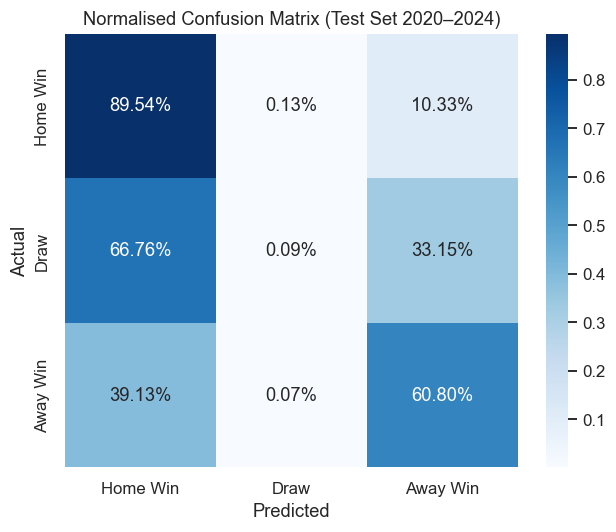

In [5]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred, normalize='true')
labels = ['Home Win', 'Draw', 'Away Win']

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=ax)
ax.set(title='Normalised Confusion Matrix (Test Set 2020–2024)',
       xlabel='Predicted', ylabel='Actual')
plt.tight_layout()
plt.savefig(FIGS / '08_confusion_matrix.png')
plt.show()

## 4. Feature Importance

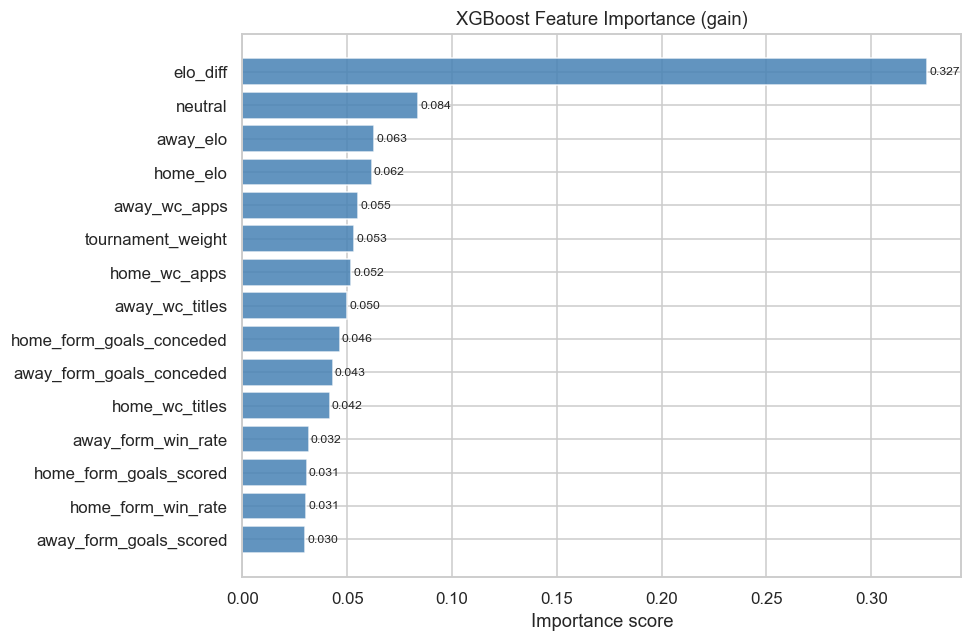


Top 5 features:
elo_diff        0.326635
neutral         0.083791
away_elo        0.062969
home_elo        0.061806
away_wc_apps    0.055329


In [6]:
importance = pd.Series(model.feature_importances_, index=FEATURE_COLS)
importance = importance.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(importance.index, importance.values, color='steelblue', alpha=0.85)
ax.set(title='XGBoost Feature Importance (gain)', xlabel='Importance score')
for bar in bars:
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.3f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig(FIGS / '09_feature_importance.png')
plt.show()

print('\nTop 5 features:')
print(importance.sort_values(ascending=False).head(5).to_string())

## 5. WC 2022 Backtest

Check how the model performed on actual World Cup 2022 matches it never saw during training (trained on pre-2020 data).

In [7]:
wc22 = df[
    (df['tournament'].str.contains('FIFA World Cup', na=False)) &
    (df['date'].dt.year == 2022)
].copy()

print(f'WC 2022 matches in dataset: {len(wc22)}')

if len(wc22) > 0:
    X_wc22 = wc22[FEATURE_COLS]
    wc22['pred']      = model.predict(X_wc22)
    wc22['correct']   = (wc22['pred'] == wc22['outcome']).astype(int)
    proba             = model.predict_proba(X_wc22)
    wc22['prob_home'] = proba[:, 0]
    wc22['prob_draw'] = proba[:, 1]
    wc22['prob_away'] = proba[:, 2]

    acc_wc22 = wc22['correct'].mean()
    ll_wc22  = log_loss(wc22['outcome'], proba)

    print(f'WC 2022 accuracy  : {acc_wc22:.3f}')
    print(f'WC 2022 log-loss  : {ll_wc22:.4f}')
    print()

    OUTCOME_MAP = {0: 'Home Win', 1: 'Draw', 2: 'Away Win'}
    display_cols = ['date','home_team','away_team','outcome','pred','correct','prob_home','prob_draw','prob_away']
    disp = wc22[display_cols].copy()
    disp['outcome'] = disp['outcome'].map(OUTCOME_MAP)
    disp['pred']    = disp['pred'].map(OUTCOME_MAP)
    disp['date']    = disp['date'].dt.date
    for col in ['prob_home','prob_draw','prob_away']:
        disp[col] = disp[col].map('{:.1%}'.format)
    print(disp.to_string(index=False))
else:
    print('No WC 2022 matches in features dataset — they may pre-date the 1990 filter or have different tournament names.')
    wc22_raw = pd.read_csv(PROC / 'results_clean.csv')
    wc22_raw = wc22_raw[wc22_raw['tournament'].str.contains('FIFA World Cup', na=False)]
    print('Tournaments matching FIFA World Cup:', wc22_raw['tournament'].unique())

WC 2022 matches in dataset: 164
WC 2022 accuracy  : 0.579
WC 2022 log-loss  : 0.9314

      date            home_team            away_team  outcome     pred  correct prob_home prob_draw prob_away
2022-01-27            Australia              Vietnam Home Win Home Win        1     79.6%     13.6%      6.8%
2022-01-27                Japan                China Home Win Home Win        1     80.2%     13.5%      6.3%
2022-01-27         Saudi Arabia                 Oman Home Win Home Win        1     67.4%     22.0%     10.6%
2022-01-27 United Arab Emirates                Syria Home Win Home Win        1     63.6%     23.5%     12.9%
2022-01-27             Paraguay              Uruguay Away Win Home Win        0     38.9%     26.6%     34.5%
2022-01-27                Chile            Argentina Away Win Away Win        1     26.1%     22.1%     51.8%
2022-01-27              Ecuador               Brazil     Draw Away Win        0     23.5%     28.6%     47.9%
2022-01-27                 Iran   

## 6. Predicted Win Probabilities for Top Teams (test set)

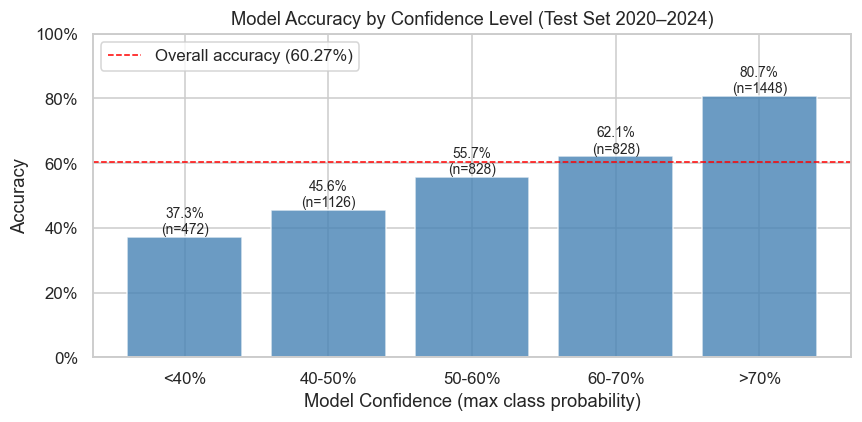

          accuracy  n_matches
conf_bin                     
<40%      0.372881        472
40-50%    0.456483       1126
50-60%    0.556763        828
60-70%    0.620773        828
>70%      0.807320       1448


In [8]:
# Probability calibration check: how often does the model's top-confidence pick win?
test_copy = test.copy()
proba_test = model.predict_proba(X_test)
test_copy['max_prob']  = proba_test.max(axis=1)
test_copy['pred']      = model.predict(X_test)
test_copy['correct']   = (test_copy['pred'] == test_copy['outcome']).astype(int)

# Bin by confidence
bins = [0, 0.40, 0.50, 0.60, 0.70, 1.01]
labels_b = ['<40%', '40-50%', '50-60%', '60-70%', '>70%']
test_copy['conf_bin'] = pd.cut(test_copy['max_prob'], bins=bins, labels=labels_b)

cal = test_copy.groupby('conf_bin', observed=True)['correct'].agg(['mean','count'])
cal.columns = ['accuracy', 'n_matches']

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(cal.index, cal['accuracy'], color='steelblue', alpha=0.8, edgecolor='white')
ax.axhline(acc, color='red', linestyle='--', linewidth=1, label=f'Overall accuracy ({acc:.2%})')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set(title='Model Accuracy by Confidence Level (Test Set 2020–2024)',
       xlabel='Model Confidence (max class probability)', ylabel='Accuracy')
ax.set_ylim(0, 1)
for bar, (_, row) in zip(bars, cal.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{row["accuracy"]:.1%}\n(n={int(row["n_matches"])})',
            ha='center', fontsize=9)
ax.legend()
plt.tight_layout()
plt.savefig(FIGS / '10_calibration.png')
plt.show()

print(cal.to_string())

## 7. Save Model

In [9]:
model_path = PROC / 'xgb_model.pkl'
joblib.dump({'model': model, 'feature_cols': FEATURE_COLS}, model_path)

sep = '=' * 52
print(sep)
print('  MODEL TRAINING  —  SUMMARY')
print(sep)
print(f'  Algorithm        : XGBClassifier (multi:softprob)')
print(f'  Training rows    : {len(train):>8,}')
print(f'  Test rows        : {len(test):>8,}')
print(f'  Best iteration   : {model.best_iteration:>8}')
print(f'  Test accuracy    : {acc:>8.3f}  (baseline {baseline_acc:.3f})')
print(f'  Test log-loss    : {ll:>8.4f}')
if len(wc22) > 0:
    print(f'  WC 2022 accuracy : {acc_wc22:>8.3f}')
print(sep)
print(f'  Model saved to: {model_path}')
print(sep)

  MODEL TRAINING  —  SUMMARY
  Algorithm        : XGBClassifier (multi:softprob)
  Training rows    :   25,993
  Test rows        :    4,702
  Best iteration   :       87
  Test accuracy    :    0.603  (baseline 0.474)
  Test log-loss    :   0.8792
  WC 2022 accuracy :    0.579
  Model saved to: data\processed\xgb_model.pkl
